# This implements SEACells directly onto sc_data.h5ad, just to get an idea of the metacells

In [29]:
import numpy as np
import pandas as pd
import scanpy as sc
import SEACells 
import matplotlib 
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad

In [30]:
import warnings
warnings.simplefilter("ignore")

In [31]:
%matplotlib inline
sns.set_style("ticks")
matplotlib.rcParams['figure.figsize']= [4,4]
matplotlib.rcParams['figure.dpi']= 100

In [32]:
ad=sc.read_h5ad("/Users/anushka/Undergraduate-Project/updated_dataset/sc_data.h5ad.1")


In [33]:
ad

AnnData object with n_obs × n_vars = 7416 × 13061
    obs: 'aggr_num', 'umi.counts', 'gene.counts', 'library_id', 'tube_barcode', 'Seq_batch', 'Region', 'Lib_type', 'Gender', 'Donor', 'Amp_Name', 'Amp_Date', 'Amp_PCR_cyles', 'Lib_Name', 'Lib_Date', 'Replicate_Lib', 'Lib_PCR_cycles', 'Lib_PassFail', 'Cell_Capture', 'Lib_Cells', 'Mean_Reads_perCell', 'Median_Genes_perCell', 'Median_UMI_perCell', 'Saturation', 'Live_percent', 'Total_Cells', 'Live_Cells', 'method', 'exp_component_name', 'mapped_reads', 'unmapped_reads', 'nonconf_mapped_reads', 'total.reads', 'doublet.score', 'cell_type', 'cell_supertype', 'cell_label'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'keep_genes'
    uns: 'hvg'
    layers: 'log'

In [ ]:
cell_type_palette = {'Astro': (0.843137, 0.0, 0.0, 1.0),
                     'Endo': (0.54902, 0.235294, 1.0, 1.0),
                     'L23_IT': (0.007843, 0.533333, 0.0, 1.0),
                     'L45_IT': (0.0, 0.67451, 0.780392, 1.0),
                     'L56_NP': (0.596078, 1.0, 0.0, 1.0),
                     'L5_ET': (1.0, 0.498039, 0.819608, 1.0),
                     'L5_IT': (0.423529, 0.0, 0.309804, 1.0),
                     'L5_PT': (1.0, 0.647059, 0.188235, 1.0),
                     'L6_CT': (0.345098, 0.231373, 0.0, 1.0),
                     'L6_IT': (0.0, 0.341176, 0.34902, 1.0),
                     'L6_IT_Car3': (0.0, 0.0, 0.866667, 1.0),
                     'L6b': (0.0, 0.992157, 0.811765, 1.0),
                     'Lamp5': (0.631373, 0.458824, 0.415686, 1.0),
                     'Microglia': (0.737255, 0.717647, 1.0, 1.0),
                     'OPC': (0.584314, 0.709804, 0.470588, 1.0),
                     'Oligo': (0.752941, 0.015686, 0.72549, 1.0),
                     'Pericytes': (0.392157, 0.329412, 0.454902, 1.0),
                     'Pvalb': (0.47451, 0.0, 0.0, 1.0),
                     'SMC': (0.027451, 0.454902, 0.847059, 1.0),
                     'Sncg': (0.996078, 0.960784, 0.564706, 1.0),
                     'Sst': (0.0, 0.294118, 0.0, 1.0),
                     'VLMC': (0.560784, 0.478431, 0.0, 1.0),
                     'Vip': (1.0, 0.447059, 0.4, 1.0)}

cell_label_palette = {'GABAergic': (0.843137, 0.0, 0.0, 1.0),
                      'Glutamatergic': (0.54902, 0.235294, 1.0, 1.0),
                      'Non-Neuronal': (0.007843, 0.533333, 0.0, 1.0)}

In [35]:
ad.uns["celltype_colors"] = cell_type_palette
ad.uns["cell_label_colors"] = cell_label_palette  

In [40]:
ad.obs_keys

<bound method AnnData.obs_keys of AnnData object with n_obs × n_vars = 7416 × 13061
    obs: 'aggr_num', 'umi.counts', 'gene.counts', 'library_id', 'tube_barcode', 'Seq_batch', 'Region', 'Lib_type', 'Gender', 'Donor', 'Amp_Name', 'Amp_Date', 'Amp_PCR_cyles', 'Lib_Name', 'Lib_Date', 'Replicate_Lib', 'Lib_PCR_cycles', 'Lib_PassFail', 'Cell_Capture', 'Lib_Cells', 'Mean_Reads_perCell', 'Median_Genes_perCell', 'Median_UMI_perCell', 'Saturation', 'Live_percent', 'Total_Cells', 'Live_Cells', 'method', 'exp_component_name', 'mapped_reads', 'unmapped_reads', 'nonconf_mapped_reads', 'total.reads', 'doublet.score', 'cell_type', 'cell_supertype', 'cell_label'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'keep_genes'
    uns: 'hvg', 'celltype_colors', 'cell_label_colors'
    layers: 'log'>

## Plotting cell types for refernce

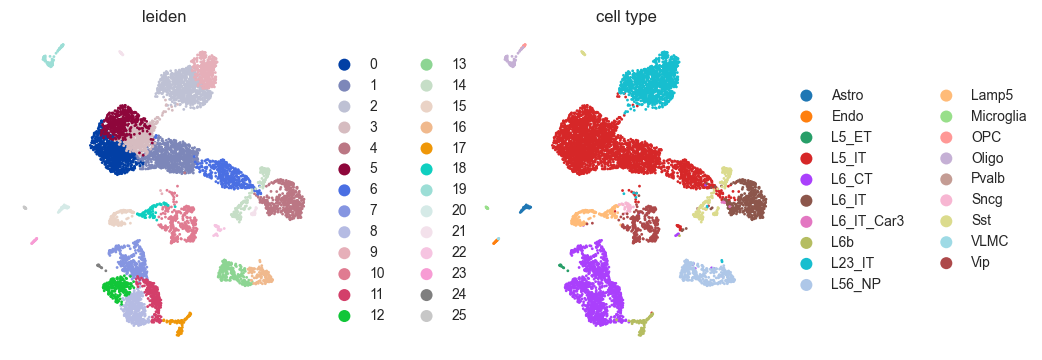

In [44]:
sc.pp.normalize_total(ad, target_sum=1e4)
sc.pp.log1p(ad)
sc.pp.highly_variable_genes(ad, n_top_genes=1500)
ad = ad[:, ad.var.highly_variable]
sc.tl.pca(ad, svd_solver='arpack')
sc.pp.neighbors(ad, n_neighbors=10, n_pcs=40)
sc.tl.leiden(ad)

sc.tl.umap(ad)
sc.pl.scatter(ad, basis='umap', color=['leiden', 'cell_type'], frameon=False)

## Preprocess

In [45]:
raw_ad=sc.AnnData(ad.X)

In [46]:
raw_ad.obs_names, raw_ad.var_names=ad.obs_names, ad.var_names
ad.raw=raw_ad

In [47]:
sc.pp.pca(ad, n_comps=50, use_highly_variable=True)

## Running SeaCells

In [48]:
#Construct kernel matrix

n_SEACells=99
build_kernel_on='X_pca'
n_waypoint_eigs=10

In [49]:
model= SEACells.core.SEACells(ad, 
                              build_kernel_on= build_kernel_on,
                              n_SEACells=n_SEACells,
                              n_waypoint_eigs=n_waypoint_eigs,
                              convergence_epsilon=1e-5
                              )

Welcome to SEACells!


In [50]:
model.construct_kernel_matrix()
M=model.kernel_matrix

Computing kNN graph using scanpy NN ...
Computing radius for adaptive bandwidth kernel...


  0%|          | 0/7416 [00:00<?, ?it/s]

Making graph symmetric...
Parameter graph_construction = union being used to build KNN graph...
Computing RBF kernel...


  0%|          | 0/7416 [00:00<?, ?it/s]

Building similarity LIL matrix...


  0%|          | 0/7416 [00:00<?, ?it/s]

Constructing CSR matrix...


In [51]:
model.initialize_archetypes()

Building kernel on X_pca
Computing diffusion components from X_pca for waypoint initialization ... 
Done.
Sampling waypoints ...
Done.
Selecting 89 cells from waypoint initialization.
Initializing residual matrix using greedy column selection
Initializing f and g...


100%|██████████| 20/20 [00:00<00:00, 271.60it/s]

Selecting 10 cells from greedy initialization.


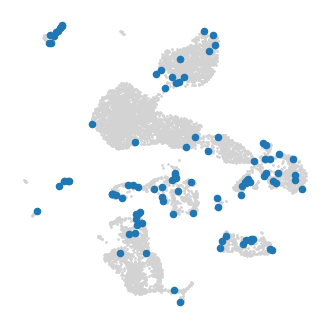

In [52]:
SEACells.plot.plot_initialization(ad, model)

In [53]:
model.fit(min_iter=10, max_iter=50)
print (f'Ran for {len(model.RSS_iters)} iterations')

Randomly initialized A matrix.
Setting convergence threshold at 0.00154
Starting iteration 1.
Completed iteration 1.
Starting iteration 10.
Completed iteration 10.
Starting iteration 20.
Completed iteration 20.
Converged after 24 iterations.
Ran for 25 iterations


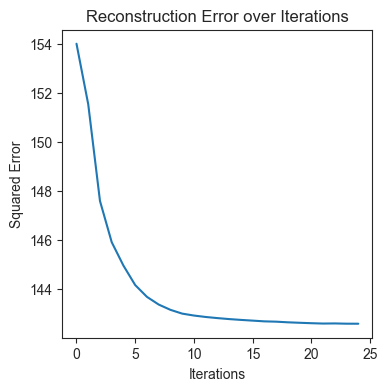

In [54]:
model.plot_convergence()

In [56]:
help(SEACells.plot.plot_2D)


Help on function plot_2D in module SEACells.plot:

plot_2D(ad, key='X_umap', colour_metacells=True, title='Metacell Assignments', save_as=None, show=True, cmap='Set2', figsize=(5, 5), SEACell_size=20, cell_size=10)
    Plot 2D visualization of metacells using the embedding provided in 'key'.
    
    :param ad: annData containing 'Metacells' label in .obs
    :param key: (str) 2D embedding of data. Default: 'X_umap'
    :param colour_metacells: (bool) whether to colour cells by metacell assignment. Default: True
    :param title: (str) title for figure
    :param save_as: (str or None) file name to which figure is saved
    :param cmap: (str) matplotlib colormap for metacells. Default: 'Set2'
    :param figsize: (int,int) tuple of integers representing figure size



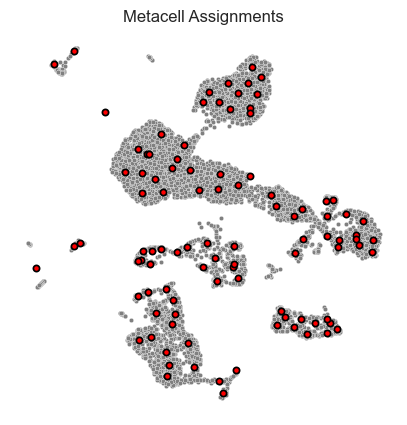

In [57]:
SEACells.plot.plot_2D(ad, colour_metacells=False)

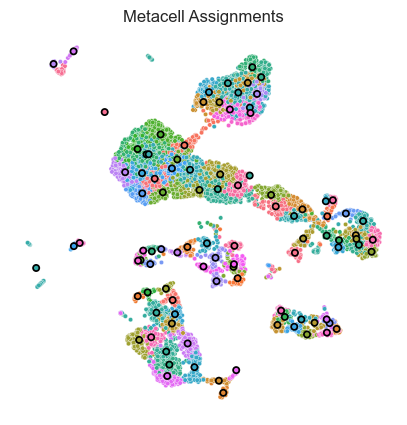

In [58]:
SEACells.plot.plot_2D(ad, colour_metacells=True)

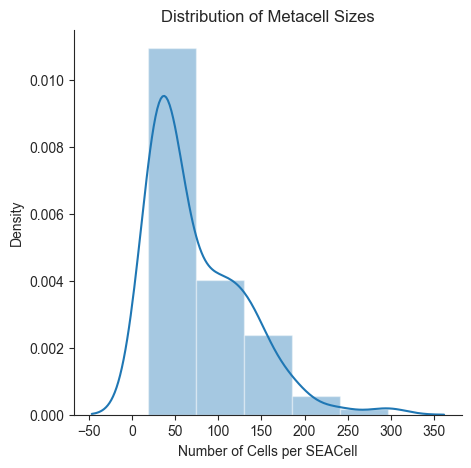

,size
SEACell,
SEACell-0,50
SEACell-1,117
SEACell-10,167
SEACell-11,40
SEACell-12,108
...,...
SEACell-94,74
SEACell-95,33
SEACell-96,148


In [59]:
SEACells.plot.plot_SEACell_sizes(ad, bins=5)